In [2]:

import math, copy
import numpy as np
import matplotlib.pyplot as plt
#plt.style.use('./deeplearning.mplstyle')
#from lab_utils_uni import plt_intuition, plt_house_x, plt_contour_wgrad, plt_divergence, plt_gradients

## Cost Function

The cost function measures how well our model is predicting the target.
It is a measure of how accurate the model is on the training data

For one variable the cost function is: 

  $J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2$
 
where 
  $f_{w,b}(x^{(i)}) = wx^{(i)} + b$
  
- $f_{w,b}(x^{(i)})$ is our prediction for example $i$ using parameters $w,b$.  
- $(f_{w,b}(x^{(i)}) -y^{(i)})^2$ is the squared difference between the target value and the prediction.   
- These differences are summed over all the $m$ examples and divided by $2m$ to produce the cost, $J(w,b)$.  


In [3]:
def compute_cost(x, y, w, b):
    """
    Computes the cost function for linear regression.
    
    Args:
      x (ndarray (m,)): Data, m examples 
      y (ndarray (m,)): target values
      w,b (scalar)    : model parameters  
    
    Returns
        total_cost (float): The cost of using w,b as the parameters for linear regression
               to fit the data points in x and y
    """
    m = x.shape[0]  # Number of training examples

    cost_sum = 0

    for i in range(m):
        f_wb = w * x[i] + b  # The predicted value for the i-th example
        cost = (f_wb - y[i]) ** 2  # Squared error for the i-th example
        cost_sum += cost  # Accumulate the cost
    total_cost = cost_sum / (2 * m)  # Average cost over all examples

    return total_cost

## Example
Let's model housing prices given the size of the house. For this example, there are only two data points.

| Size (1000 sqft)     | Price (1000s of dollars) |
| -------------------| ------------------------ |
| 1                 | 300                      |
| 2                  | 500                      |


In [4]:
x_train = np.array([1.0, 2.0])           #(size in 1000 square feet)
y_train = np.array([300.0, 500.0])           #(price in 1000s of dollars)

For linear regression we know that the model is a straight line
$f_{w,b}(x^{(i)}) = wx^{(i)} + b$

The goal is to find $w$ and $b$ such that the cost function is minimised. 

In [5]:
def compute_linear_model(x, w, b):
    """
    Computes the linear model h(x) = w*x + b for a dataset x and parameters w,b.
    
    Args:
      x (ndarray (m,)): Data, m examples 
      w,b (scalar)    : model parameters  
    
    Returns
        f_wb (ndarray (m,)): The predicted values of f_(x) using w,b as the parameters
    """
    m = x.shape[0]  # Number of training examples
    
    f_wb = np.zeros(m)

    for i in range(m):
        f_wb[i] = w * x[i] + b  # Compute the predicted value for the i-th example

    return f_wb

Let's fix $b$ to 100 for simplicity.
Assuming $w$ is 300 we would get the following

In [23]:
w = 300
b = 100

x = np.linspace(1, 3, num=10)  # Generates 10 evenly spaced values from 0 to 3
y = compute_linear_model(x, w=300, b=100)  # Compute the linear model predictions for the generated x values
cost = compute_cost(x, y, 300, 100)

w_range = np.arange(-400, 400, 10)
costs = [compute_cost(x_train, y_train, w, b) for w in w_range]


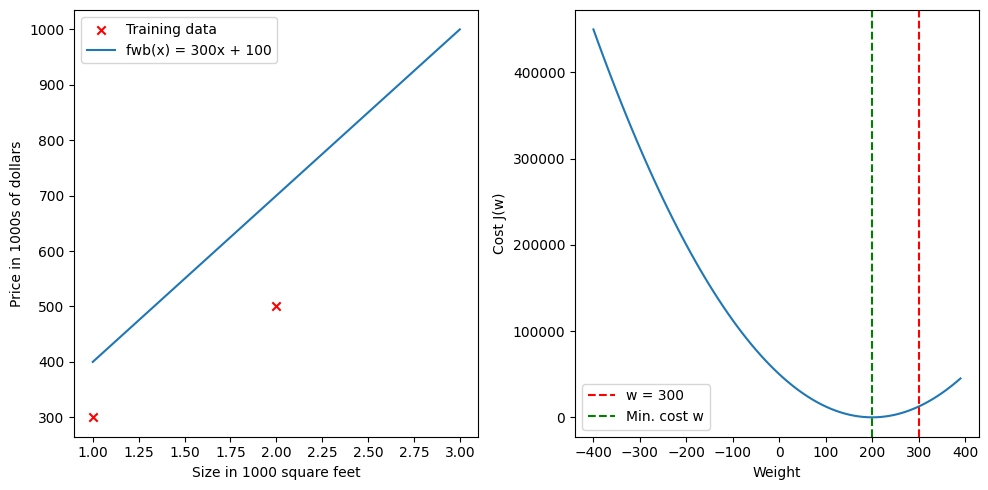

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.scatter(x_train, y_train, marker='x', c='r', label='Training data')
ax1.plot(x, y, label='fwb(x) = 300x + 100')
ax1.set_xlabel('Size in 1000 square feet')
ax1.set_ylabel('Price in 1000s of dollars')
ax1.legend()    

ax2.plot(w_range, costs)
ax2.set_xlabel('Weight')
ax2.set_ylabel('Cost J(w)')
ax2.axvline(x=w, color='r', linestyle='--', label='w = 300')
ax2.axvline(x=200, color='g', linestyle='--', label='Min. cost w')
ax2.legend()

plt.tight_layout()
plt.show()

We can see that the minimum cost occurs when $w = 200$
Thus, the parameters that mimise the cost function in this example is $w = 200$ and $b = 100$

In [30]:
y = compute_linear_model(x, w=200, b=100) 

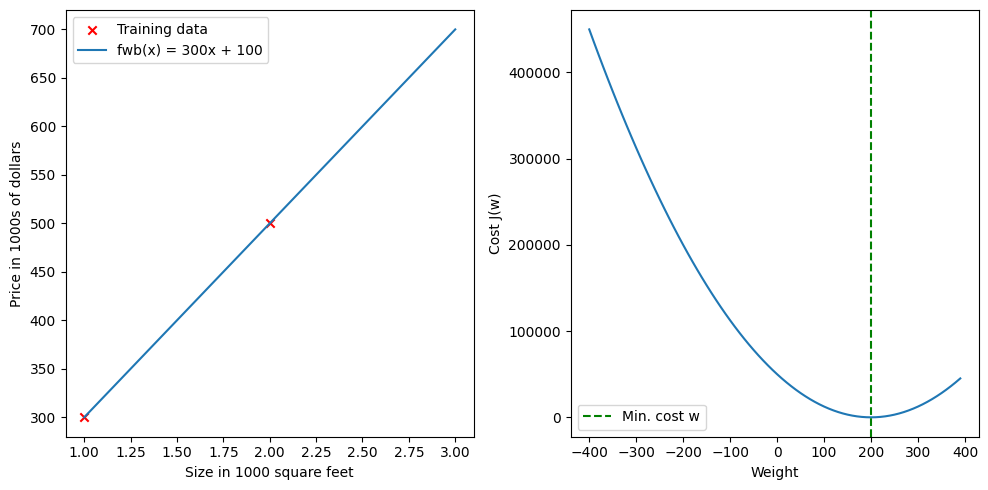

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.scatter(x_train, y_train, marker='x', c='r', label='Training data')
ax1.plot(x, y, label='fwb(x) = 300x + 100')
ax1.set_xlabel('Size in 1000 square feet')
ax1.set_ylabel('Price in 1000s of dollars')
ax1.legend()    

ax2.plot(w_range, costs)
ax2.set_xlabel('Weight')
ax2.set_ylabel('Cost J(w)')
ax2.axvline(x=200, color='g', linestyle='--', label='Min. cost w')
ax2.legend()

plt.tight_layout()
plt.show()

## 3D Cost Function Example

Let's make the dataset larger and plot the cost function over both $w$ and $b$

In [ ]:
x_train = np.array([1.0, 1.7, 2.0, 2.5, 3.0, 3.2])
y_train = np.array([250, 300, 480,  430, 630, 730,])

w_range = np.linspace(50, 400, 100)
b_range = np.linspace(-200, 200, 100)
W, B = np.meshgrid(w_range, b_range)

# computes cost over a grid of w and b values
J = np.array([[compute_cost(x_train, y_train, w, b) for w in w_range] for b in b_range])

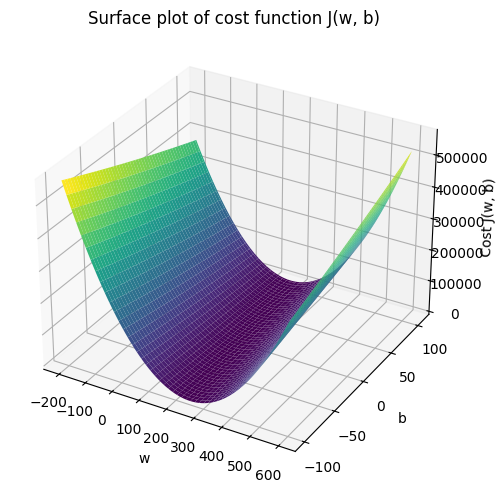

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W, B, J, cmap='viridis')
ax.set_xlabel('w')
ax.set_ylabel('b')
ax.set_zlabel('Cost J(w, b)')
ax.set_title('Surface plot of cost function J(w, b)')
plt.tight_layout()
plt.show()  